In [3]:
#Load Libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from category_encoders import TargetEncoder
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")



In [4]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

train['dataset'] = 'train'
test['dataset'] = 'test'

df = pd.concat([train, test], axis=0).reset_index(drop=True)

print("Dataset shape:", df.shape)
df

Dataset shape: (900000, 14)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,dataset
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,train
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,train
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,train
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,train
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,899995,21,other,b.com,2.55,82.3,yes,8.4,average,mixed,medium,hard,NaN,test
899996,899996,17,female,b.com,0.49,46.4,yes,8.8,good,mixed,low,easy,NaN,test
899997,899997,22,male,bba,6.62,74.7,yes,5.5,good,coaching,high,easy,NaN,test
899998,899998,22,other,ba,4.08,51.8,yes,8.7,poor,online videos,high,moderate,NaN,test


In [5]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                900000 non-null  int64  
 1   age               900000 non-null  int64  
 2   gender            900000 non-null  str    
 3   course            900000 non-null  str    
 4   study_hours       900000 non-null  float64
 5   class_attendance  900000 non-null  float64
 6   internet_access   900000 non-null  str    
 7   sleep_hours       900000 non-null  float64
 8   sleep_quality     900000 non-null  str    
 9   study_method      900000 non-null  str    
 10  facility_rating   900000 non-null  str    
 11  exam_difficulty   900000 non-null  str    
 12  exam_score        630000 non-null  float64
 13  dataset           900000 non-null  str    
dtypes: float64(4), int64(2), str(8)
memory usage: 96.1 MB


In [6]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['id', 'age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']
Categorical Columns: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'dataset']


In [7]:
# Check for missing values
df.isnull().sum()


id                       0
age                      0
gender                   0
course                   0
study_hours              0
class_attendance         0
internet_access          0
sleep_hours              0
sleep_quality            0
study_method             0
facility_rating          0
exam_difficulty          0
exam_score          270000
dataset                  0
dtype: int64

In [8]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,900000.000000,900000.000000,900000.000000,900000.000000,900000.000000,630000.000000
mean,449999.500000,20.545316,4.002800,71.985836,7.072552,62.506672
std,259807.765473,2.260301,2.359238,17.425469,1.745021,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,224999.750000,19.000000,1.980000,57.000000,5.600000,48.800000
50%,449999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,674999.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,899999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [9]:
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print("________________________________________")
    print(df[col].value_counts())


Unique values in 'gender':
________________________________________
gender
male      301275
other     301208
female    297517
Name: count, dtype: int64

Unique values in 'course':
________________________________________
course
b.tech     187697
b.sc       159266
b.com      158267
bca        126810
bba        107743
ba          88863
diploma     71354
Name: count, dtype: int64

Unique values in 'internet_access':
________________________________________
internet_access
yes    828094
no      71906
Name: count, dtype: int64

Unique values in 'sleep_quality':
________________________________________
sleep_quality
poor       305355
good       304843
average    289802
Name: count, dtype: int64

Unique values in 'study_method':
________________________________________
study_method
coaching         188395
self-study       187072
group study      175789
mixed            175778
online videos    172966
Name: count, dtype: int64

Unique values in 'facility_rating':
______________________________

<Axes: xlabel='exam_score', ylabel='Count'>

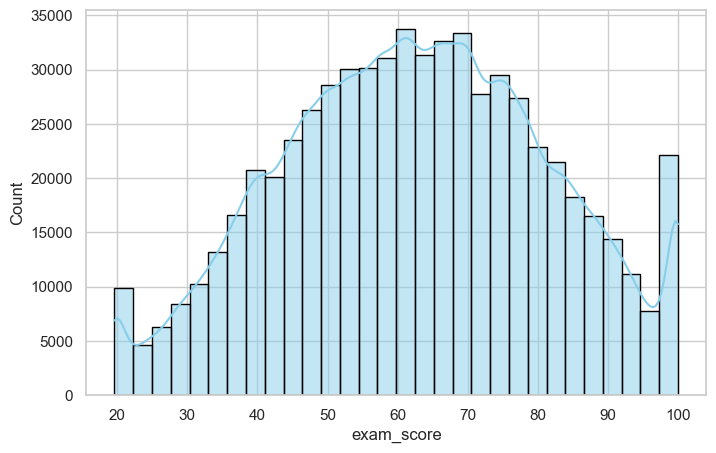

In [10]:
label='exam_score'

plt.figure(figsize=(8, 5))

sns.histplot(data=df,x=label,kde=True,bins=30,color='skyblue',edgecolor='black')

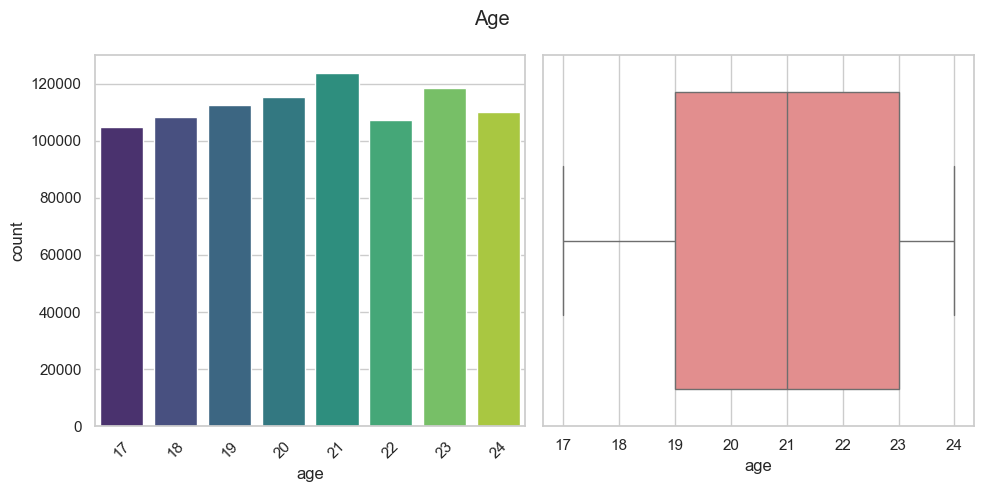


age:
 count    900000.00
mean         20.55
std           2.26
min          17.00
25%          19.00
50%          21.00
75%          23.00
max          24.00
Name: age, dtype: float64
_______________________________________________________________


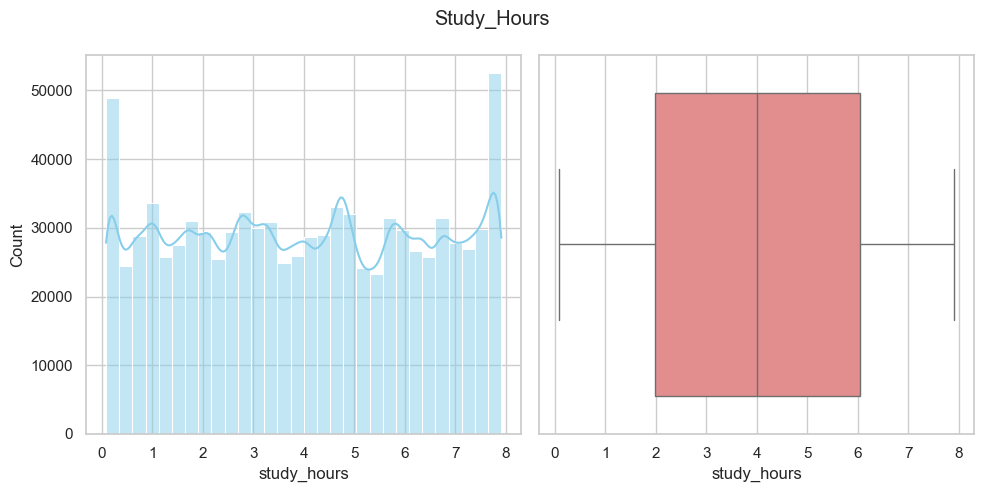


study_hours:
 count    900000.00
mean          4.00
std           2.36
min           0.08
25%           1.98
50%           4.00
75%           6.05
max           7.91
Name: study_hours, dtype: float64
_______________________________________________________________


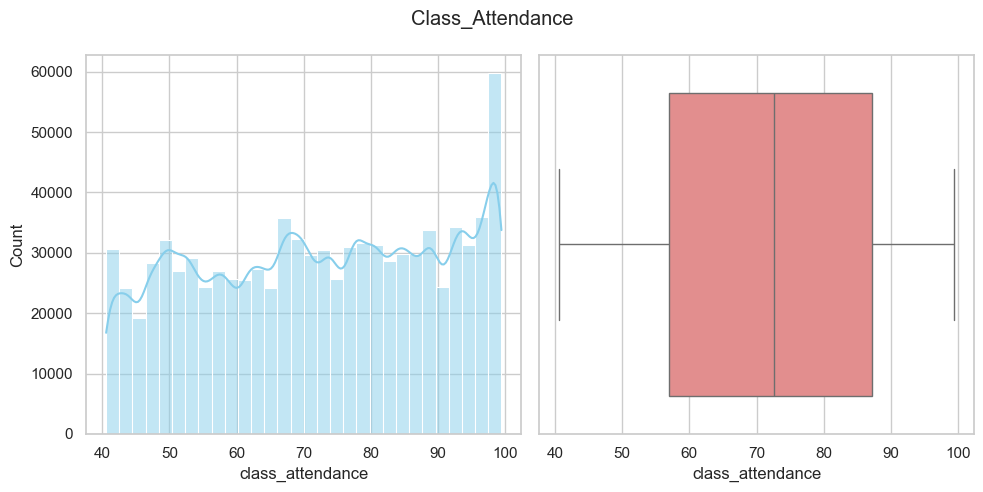


class_attendance:
 count    900000.00
mean         71.99
std          17.43
min          40.60
25%          57.00
50%          72.60
75%          87.20
max          99.40
Name: class_attendance, dtype: float64
_______________________________________________________________


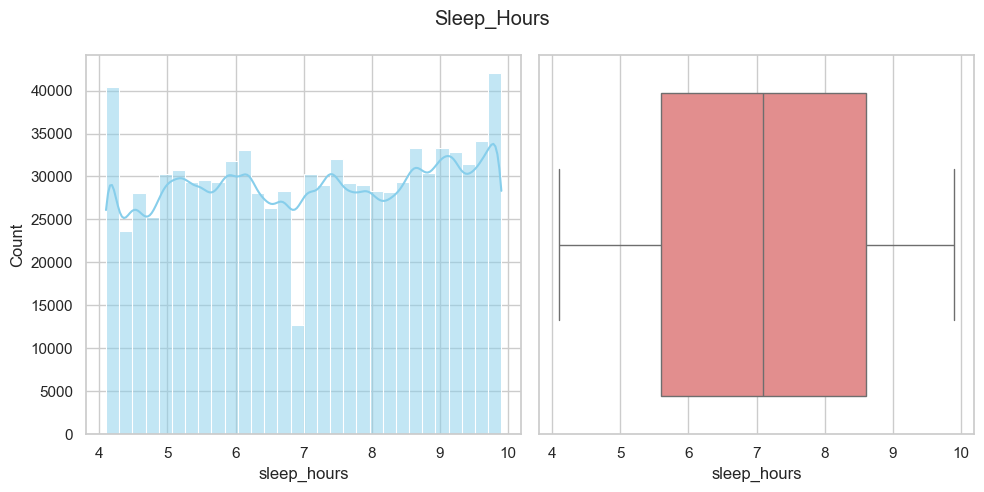


sleep_hours:
 count    900000.00
mean          7.07
std           1.75
min           4.10
25%           5.60
50%           7.10
75%           8.60
max           9.90
Name: sleep_hours, dtype: float64
_______________________________________________________________


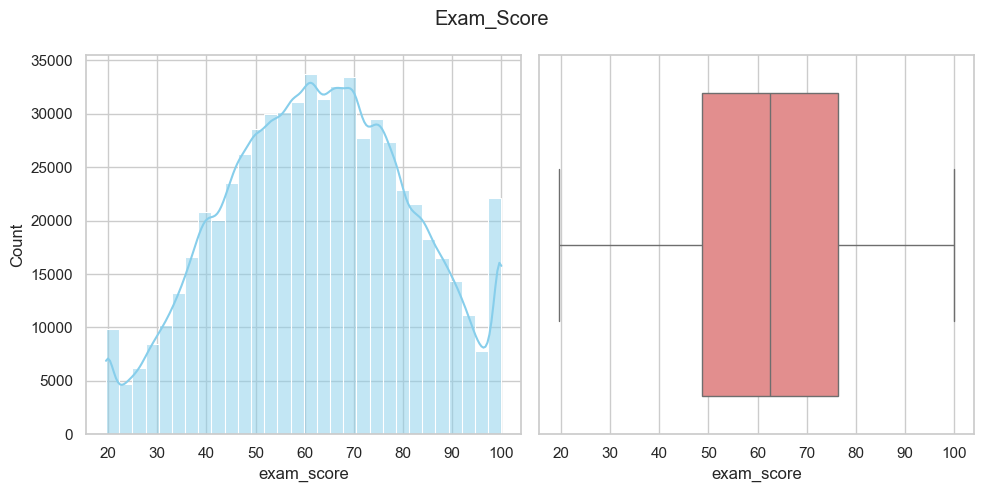


exam_score:
 count    630000.00
mean         62.51
std          18.92
min          19.60
25%          48.80
50%          62.60
75%          76.30
max         100.00
Name: exam_score, dtype: float64
_______________________________________________________________


In [11]:

EXCLUDE_COLS = ['id']
TARGET_COL = 'exam_score'

num_cols = [c for c in df.select_dtypes(include='number').columns if c not in EXCLUDE_COLS]


for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f'{col.title()}')
    data = df[col].dropna()
    
    
    if data.nunique() <= 30 and pd.api.types.is_integer_dtype(data):
        sns.countplot(x=data, ax=axes[0], palette='viridis')
        axes[0].tick_params(axis='x', rotation=45)
    else:
        sns.histplot(data, kde=True, bins=30, ax=axes[0], color='skyblue')
    
    
    sns.boxplot(x=data, ax=axes[1], color='lightcoral')
    
    plt.tight_layout()
    plt.show()
    print(f"\n{col}:\n", data.describe().round(2))
    print("_______________________________________________________________")

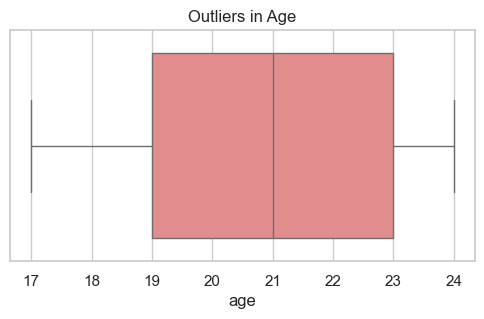

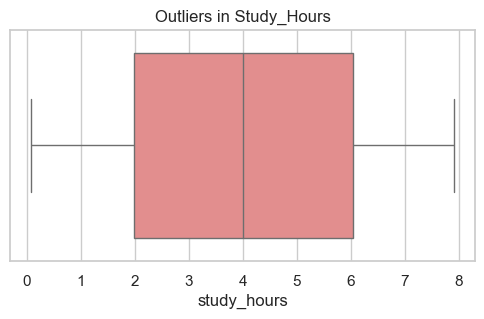

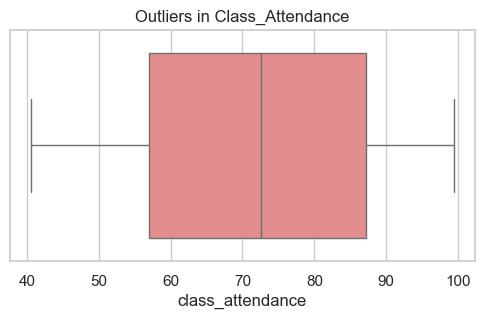

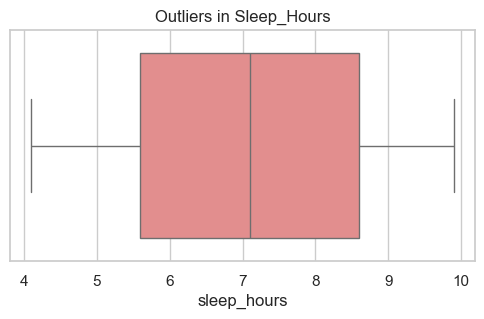

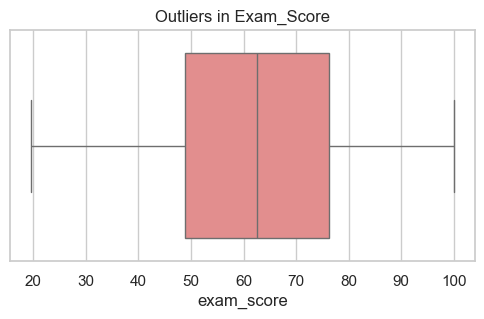

In [12]:

numerical_cols = df.select_dtypes(include='number').columns.drop('id', errors='ignore')

for col in numerical_cols:
    title = col.title()
    plt.figure(figsize=(6, 3)) 
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Outliers in {title}')
    plt.show() 

### SCORE_COL = "exam_score"
### THRESHOLD = 60                      
### TARGET_COL = "high_score_flag" 


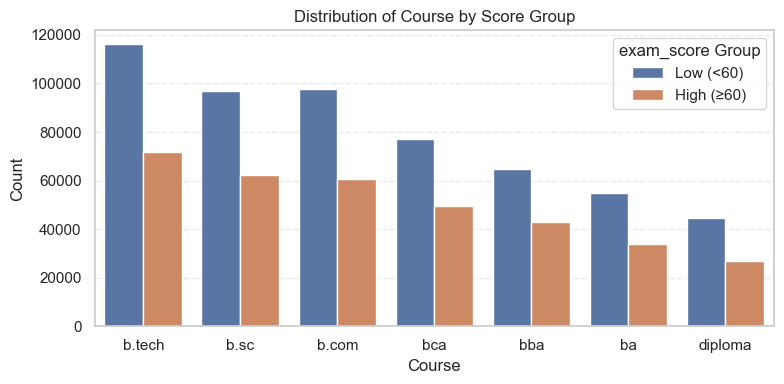

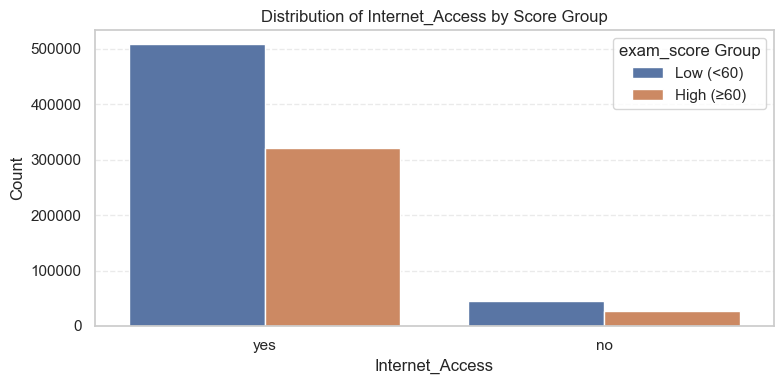

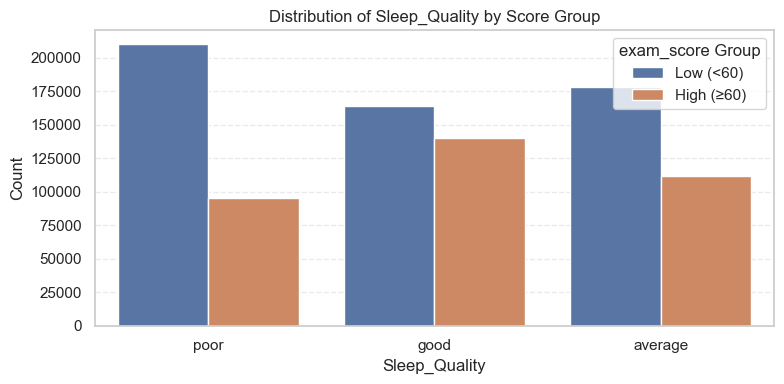

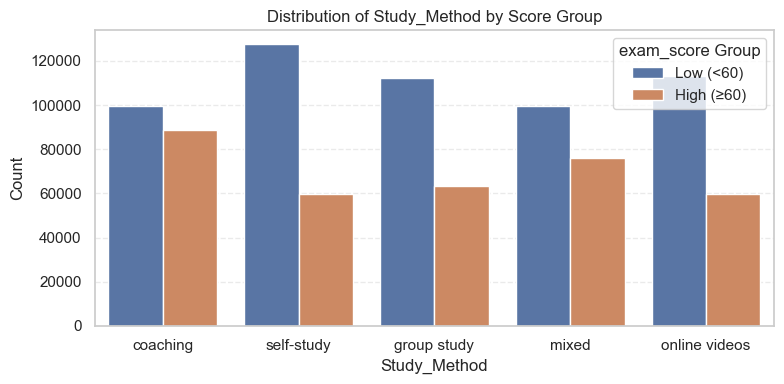

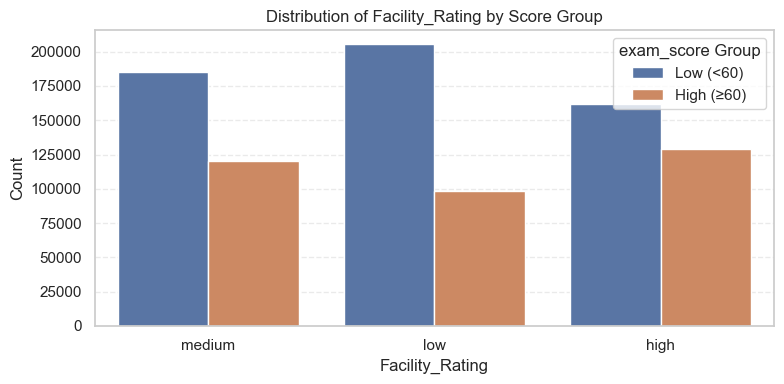

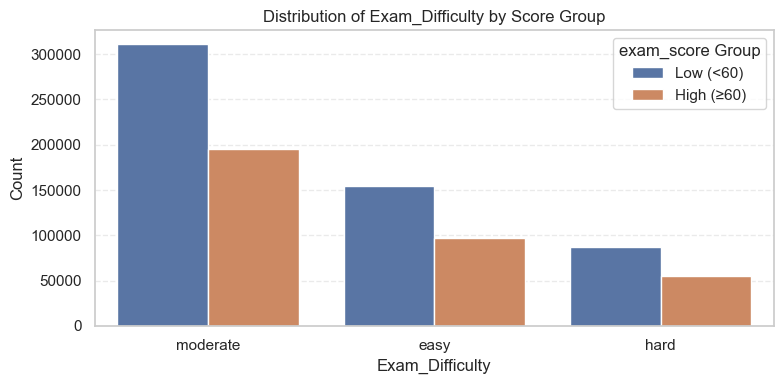

In [13]:
# SCORE_COL = "exam_score"
# THRESHOLD = 60                      
# TARGET_COL = "high_score_flag"      

cols_to_plot = [
    "course",
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

df['high_score_flag'] = (df['exam_score'] >= 60).astype("Int64") 
plot_df = df.dropna(subset=['high_score_flag']).copy()

#  Categorical Feature Distributions by Target
for col in cols_to_plot:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=plot_df,
        x=col,
        hue="high_score_flag" ,
        order=plot_df[col].value_counts().index
    )

    plt.title(f'Distribution of {col.title()} by Score Group')
    plt.xlabel(col.title())
    plt.ylabel('Count')


    plt.legend(
        title=f'{'exam_score'} Group',
        labels=[f'Low (<{60})', f'High (≥{60})']
    )

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

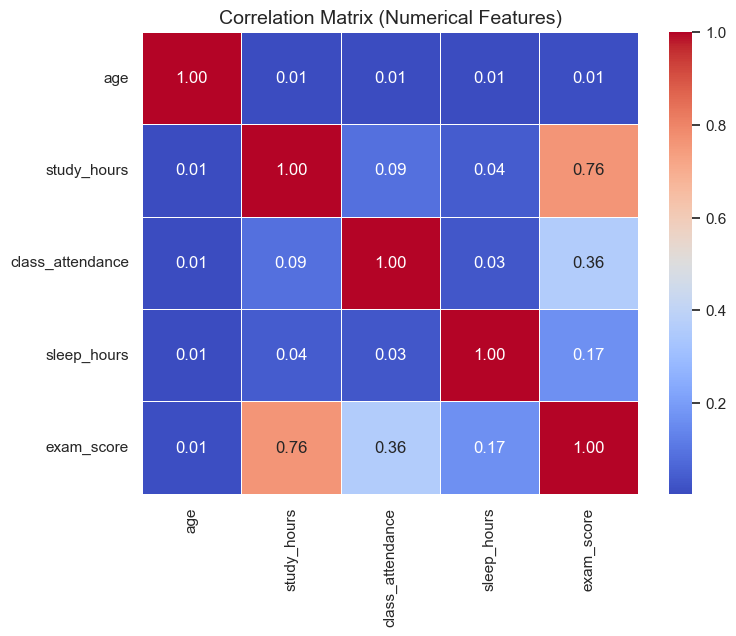

In [14]:
num_cols = [
    'age',
    'study_hours',
    'class_attendance',
    'sleep_hours',
    'exam_score'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix (Numerical Features)', fontsize=14)
plt.show()

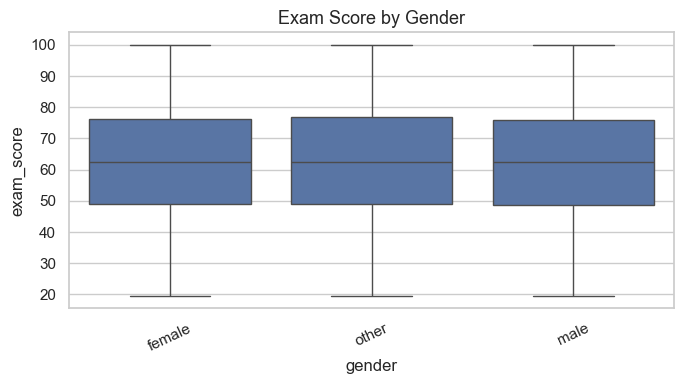

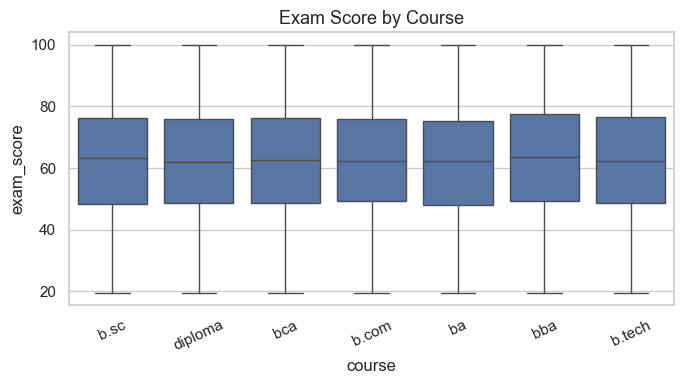

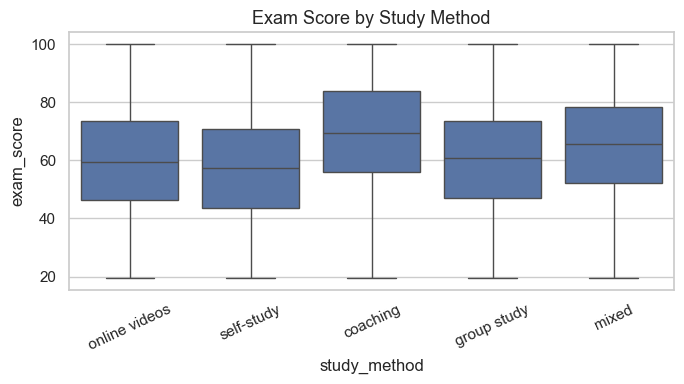

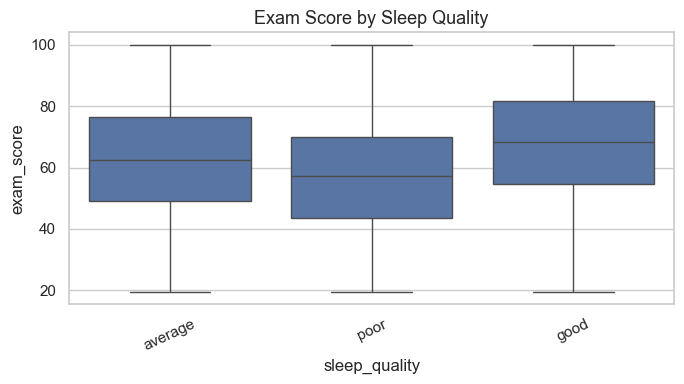

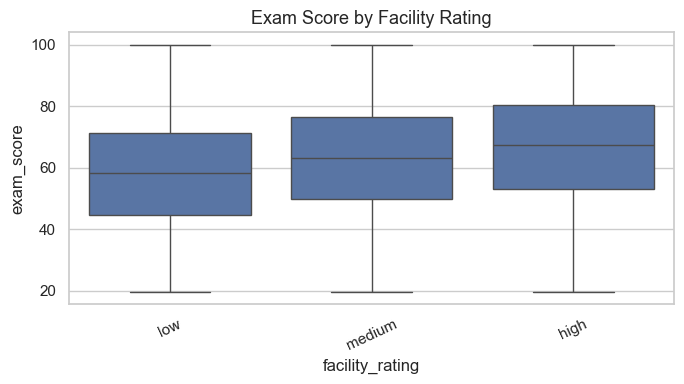

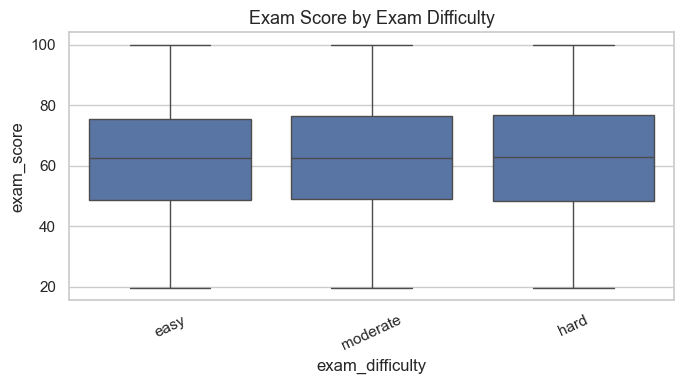

In [15]:
cat_cols = [
    'gender',
    'course',
    'study_method',
    'sleep_quality',
    'facility_rating',
    'exam_difficulty'
]

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        x=col,
        y='exam_score'
    )
    plt.title(f'Exam Score by {col.replace("_"," ").title()}', fontsize=13)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

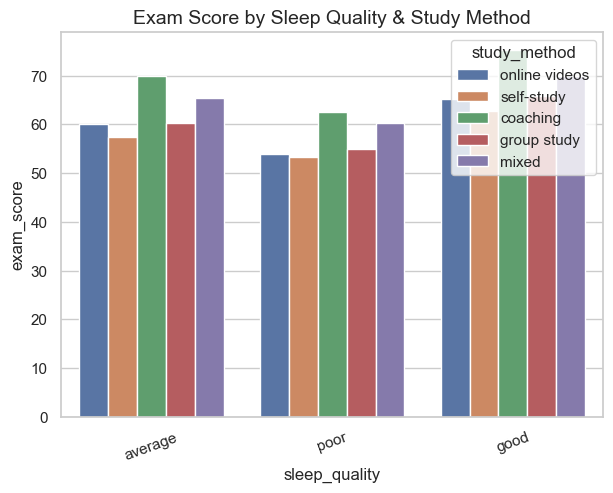

In [16]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x='sleep_quality',
    y='exam_score',
    hue='study_method',
    ci=None
)
plt.title('Exam Score by Sleep Quality & Study Method', fontsize=14)
plt.xticks(rotation=20)
plt.show()

In [17]:
df

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,dataset,high_score_flag
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,train,1
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,train,0
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,train,1
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,train,1
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,train,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,899995,21,other,b.com,2.55,82.3,yes,8.4,average,mixed,medium,hard,NaN,test,0
899996,899996,17,female,b.com,0.49,46.4,yes,8.8,good,mixed,low,easy,NaN,test,0
899997,899997,22,male,bba,6.62,74.7,yes,5.5,good,coaching,high,easy,NaN,test,0
899998,899998,22,other,ba,4.08,51.8,yes,8.7,poor,online videos,high,moderate,NaN,test,0


####  TARGET_COL = "exam_score"
####  ID_COL = "id"
####  SPLIT_COL = "dataset"

In [18]:

TARGET_COL = "exam_score"
ID_COL = "id"
SPLIT_COL = "dataset"

train_df = df[df[SPLIT_COL] == "train"].dropna(subset=[TARGET_COL]).copy()
test_df = df[df[SPLIT_COL] == "test"].copy()

X_train = train_df.drop(columns=[ID_COL, TARGET_COL, SPLIT_COL])
y_train = train_df[TARGET_COL]
X_test = test_df.drop(columns=[ID_COL, TARGET_COL, SPLIT_COL])


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("target_enc", TargetEncoder(smoothing=25.0), cat_cols),
    ("scaler", StandardScaler(), num_cols)
])

preprocessor.fit(X_train, y_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)



# XGBRegressor

In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score

# MODEL
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=7,
    subsample=0.82,
    colsample_bytree=0.52,
    reg_alpha=0.3,
    reg_lambda=8.0,
    random_state=42,
    tree_method="hist",
    device="cuda"
)


kfold = KFold(n_splits=10, shuffle=True, random_state=42)
mae=cross_val_score(model, X_train_processed, y_train, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
rmse = cross_val_score(model, X_train_processed, y_train, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
r2 = cross_val_score(model, X_train_processed, y_train, cv=kfold, scoring='r2', n_jobs=-1)



In [23]:
model.fit(X_train_processed, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.52
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabet

In [24]:
y_pred = model.predict(X_test_processed)
import joblib
joblib.dump(model, 'xgboost_model.pkl')

['xgboost_model.pkl']

In [20]:
print(f"CV RMSE: {-rmse.mean():.4f} ")
print(f"CV R²:   {r2.mean():.4f} ")

CV RMSE: 7.3122 
CV R²:   0.8506 


In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000]
}

scoring_metrics = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1 
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (RMSE):", -grid_search.best_score_)

best_model = grid_search.best_estimator_


# RandomForestRegressor

In [22]:
RF = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validation for RF
rf_mae = cross_val_score(RF, X_train_processed, y_train, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_rmse = cross_val_score(RF, X_train_processed, y_train, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_r2 = cross_val_score(RF, X_train_processed, y_train, cv=kfold, scoring='r2', n_jobs=-1)

# Grid Search for RF
param_grid_rf = {
    'max_depth': [5, 8, 10],
    'n_estimators': [100, 300, 500],
    'min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=RF, 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search_rf.fit(X_train_processed, y_train)
best_rf = grid_search_rf.best_estimator_

print("="*50)
print("RandomForestRegressor Results:")
print("="*50)
print(f"CV RMSE: {-rf_rmse.mean():.4f} (+/- {rf_rmse.std():.4f})")
print(f"CV R²:   {rf_r2.mean():.4f} (+/- {rf_r2.std():.4f})")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Score (RMSE): {-grid_search_rf.best_score_:.4f}")
print("="*50)


RandomForestRegressor Results:
CV RMSE: 7.8128 (+/- 0.0187)
CV R²:   0.8294 (+/- 0.0009)
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
Best Score (RMSE): 7.5400


# GradientBoostingRegressor

In [ ]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    random_state=42
)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validation for GBR
gbr_mae = cross_val_score(gbr, X_train_processed, y_train, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
gbr_rmse = cross_val_score(gbr, X_train_processed, y_train, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
gbr_r2 = cross_val_score(gbr, X_train_processed, y_train, cv=kfold, scoring='r2', n_jobs=-1)

# Grid Search for GBR
param_grid_gbr = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

grid_search_gbr = GridSearchCV(
    estimator=gbr, 
    param_grid=param_grid_gbr, 
    cv=5, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search_gbr.fit(X_train_processed, y_train)
best_gbr = grid_search_gbr.best_estimator_

print("="*50)
print("GradientBoostingRegressor Results:")
print("="*50)
print(f"CV RMSE: {-gbr_rmse.mean():.4f} (+/- {gbr_rmse.std():.4f})")
print(f"CV R²:   {gbr_r2.mean():.4f} (+/- {gbr_r2.std():.4f})")
print(f"Best Parameters: {grid_search_gbr.best_params_}")
print(f"Best Score (RMSE): {-grid_search_gbr.best_score_:.4f}")
print("="*50)


# Model Comparison & Selection

In [ ]:
import pickle
import pandas as pd

# Collect all model results
results = {
    'XGBRegressor': {
        'model': best_model,
        'cv_rmse': -rmse.mean(),
        'cv_r2': r2.mean(),
        'best_score': -grid_search.best_score_,
        'params': grid_search.best_params_
    },
    'RandomForestRegressor': {
        'model': best_rf,
        'cv_rmse': -rf_rmse.mean(),
        'cv_r2': rf_r2.mean(),
        'best_score': -grid_search_rf.best_score_,
        'params': grid_search_rf.best_params_
    },
    'GradientBoostingRegressor': {
        'model': best_gbr,
        'cv_rmse': -gbr_rmse.mean(),
        'cv_r2': gbr_r2.mean(),
        'best_score': -grid_search_gbr.best_score_,
        'params': grid_search_gbr.best_params_
    }
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'CV RMSE': [results[m]['cv_rmse'] for m in results.keys()],
    'CV R²': [results[m]['cv_r2'] for m in results.keys()],
    'Best Score (RMSE)': [results[m]['best_score'] for m in results.keys()]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Find best model (lowest RMSE)
best_model_name = comparison_df.loc[comparison_df['CV RMSE'].idxmin(), 'Model']
best_model_obj = results[best_model_name]['model']
best_rmse = results[best_model_name]['CV RMSE']
best_r2 = results[best_model_name]['CV R²']

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  RMSE: {best_rmse:.4f}")
print(f"  R²: {best_r2:.4f}")
print(f"  Parameters: {results[best_model_name]['params']}")


In [ ]:
# Save best model to pkl file
pkl_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl'

with open(pkl_filename, 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"\n✓ Model saved to: {pkl_filename}")

# Also save the preprocessor
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✓ Preprocessor saved to: preprocessor.pkl")

# Create predictions on test set with best model
y_test_pred = best_model_obj.predict(X_test_processed)

print(f"\nTest predictions shape: {y_test_pred.shape}")
print(f"Test predictions (first 10): {y_test_pred[:10]}")


In [ ]:

print("\n" + "="*70)
print("RE-TRAINING PREPROCESSOR (WITHOUT 'dataset' COLUMN)")
print("="*70)

# Re-load original data
train_original = pd.read_csv("train.csv")
test_original = pd.read_csv("test.csv")

# Prepare training data WITHOUT 'dataset' column
X_train_clean = train_original[['age', 'gender', 'course', 'study_hours', 'class_attendance', 
                                 'internet_access', 'sleep_hours', 'sleep_quality', 
                                 'study_method', 'facility_rating', 'exam_difficulty']].copy()

y_train_clean = train_original['exam_score'].copy()

X_test_clean = test_original[['age', 'gender', 'course', 'study_hours', 'class_attendance', 
                               'internet_access', 'sleep_hours', 'sleep_quality', 
                               'study_method', 'facility_rating', 'exam_difficulty']].copy()

print(f"\nTraining data shape: {X_train_clean.shape}")
print(f"Test data shape: {X_test_clean.shape}")
print(f"Columns: {X_train_clean.columns.tolist()}")

# Create NEW preprocessor (same as before but trained correctly)
cat_cols_clean = ['gender', 'course', 'internet_access', 'sleep_quality', 
                  'study_method', 'facility_rating', 'exam_difficulty']
num_cols_clean = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

preprocessor_fixed = ColumnTransformer([
    ("target_enc", TargetEncoder(smoothing=25.0), cat_cols_clean),
    ("scaler", StandardScaler(), num_cols_clean)
])

print("\nFitting new preprocessor...")
preprocessor_fixed.fit(X_train_clean, y_train_clean)
print("SUCCESS: Preprocessor trained without 'dataset' column")

# Save the FIXED preprocessor
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor_fixed, f)
print("\nSaved to: preprocessor.pkl (FIXED VERSION)")

# Verify by transforming test data
X_test_transformed = preprocessor_fixed.transform(X_test_clean)
print(f"\nVerification - Transformed test shape: {X_test_transformed.shape}")
print("SUCCESS: Preprocessor works correctly!")


In [ ]:

# Save the best model again (to ensure it matches the fixed preprocessor)
pkl_filename = f'xgboost_model.pkl'

with open(pkl_filename, 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"Saved to: {pkl_filename}")

print("\n" + "="*70)
print("FINAL TESTING: MODEL + PREPROCESSOR")
print("="*70)

# Test with sample data
test_single = pd.DataFrame({
    'age': [20],
    'gender': ['male'],
    'course': ['b.tech'],
    'study_hours': [6.0],
    'class_attendance': [75.0],
    'internet_access': ['yes'],
    'sleep_hours': [7.0],
    'sleep_quality': ['good'],
    'study_method': ['group study'],
    'facility_rating': ['medium'],
    'exam_difficulty': ['moderate']
})

print("\nTest input data:")
print(test_single.to_string())

# Transform
test_transformed = preprocessor_fixed.transform(test_single)
print(f"\nTransformed shape: {test_transformed.shape}")

# Predict
prediction = best_model_obj.predict(test_transformed)[0]
print(f"\nPredicted Score: {prediction:.2f}/100")

grade = "A" if prediction >= 85 else "B" if prediction >= 70 else "C" if prediction >= 50 else "D"
print(f"Grade: {grade}")

print("\n" + "="*70)
print("ALL FILES SAVED CORRECTLY")
print("="*70)
print("Files ready for deployment:")
print("  - xgboost_model.pkl")
print("  - preprocessor.pkl (FIXED - no 'dataset' column)")
print("\nYour Flask/Streamlit apps will now work without errors!")


In [ ]:
# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'].values,
    'exam_score': y_test_pred
})

submission.to_csv('submission.csv', index=False)

print("\n" + "="*70)
print("SUBMISSION FILE CREATED")
print("="*70)
print(f"Shape: {submission.shape}")
print(f"\nFirst 5 rows:")
print(submission.head())
print(f"\nSaved to: submission.csv")
print("="*70)
